In [ ]:
# requires matplotlib 3.7.3

import os
import time
import argparse
import math
import numpy as np
import open3d as o3d
import time
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt

from graspnetAPI.grasp import Grasp
from graspnetAPI import GraspGroup

from symmetry import *
from utils import display_pointcloud;
from hts_grasps import HTSGrasp, HTSGraspGroup

ModuleNotFoundError: No module named 'geometry_msgs'

In [305]:
POINTCLOUD_FILE = "/ros2_ws/src/pointclouds/conic_flask.npz"
POINTCLOUD_GRASPS = "/ros2_ws/src/grasp_groups/conic"

points = np.load(POINTCLOUD_FILE)["points"]
colours = np.zeros_like(points, dtype=np.float64)

z_coords: npt.NDArray[np.float64] = points[:, 2]
y_coords: npt.NDArray[np.float64] = points[:, 1]
x_coords: npt.NDArray[np.float64] = points[:, 0]
mask = (z_coords > 0.001) & (z_coords < 2.0) & ((0.3 - x_coords)**2 + (0.0 - y_coords)**2 < 0.08**2)
        
cropped_points: npt.NDArray[np.float64] = points[mask].astype(np.float64)
cropped_colours: npt.NDArray[np.float64] = colours[mask].astype(np.float64)
uncropped_points: npt.NDArray[np.float64] = points[~mask].astype(np.float64)
uncropped_colours: npt.NDArray[np.float64] = colours[~mask].astype(np.float64)

cloud: o3d.geometry.PointCloud = o3d.geometry.PointCloud()
cloud.points = o3d.utility.Vector3dVector(cropped_points)
len(cropped_points)

5133

In [306]:
gg = GraspNetGroup()
gg.from_npy(f"{POINTCLOUD_GRASPS}/anygrasp_output_grasps.npy")
len(gg)

850

In [307]:
exclude_grasps: list[int] = []
for ind, grasp in enumerate(gg):
    # exclude grasps by orientation
    roll, pitch, yaw = Rotation.from_matrix(grasp.rotation_matrix).as_euler('xyz', degrees=True)
    if abs(pitch) > 10 and abs(pitch - 180) > 10:
        exclude_grasps.append(ind)
        continue
    if abs(roll) > 10 and abs(roll - 180) > 10:
        exclude_grasps.append(ind)
        continue
gg.remove(exclude_grasps)
len(gg)

169

In [308]:
def create_hollow_cylinder(r_outer=1.0, r_inner=0.6, height=2.0, resolution=64):
    h = height / 2
    vertices = []
    triangles = []

    for i in range(resolution):
        theta = 2 * np.pi * i / resolution
        c, s = np.cos(theta), np.sin(theta)

        # outer wall
        vertices.append([r_outer * c, r_outer * s,  h])
        vertices.append([r_outer * c, r_outer * s, -h])

        # inner wall
        vertices.append([r_inner * c, r_inner * s,  h])
        vertices.append([r_inner * c, r_inner * s, -h])

    def idx(i, k):
        return 4 * (i % resolution) + k

    for i in range(resolution):
        ni = (i + 1) % resolution

        # outer wall
        triangles += [
            [idx(i,0), idx(ni,0), idx(i,1)],
            [idx(i,1), idx(ni,0), idx(ni,1)]
        ]

        # inner wall
        triangles += [
            [idx(i,2), idx(i,3), idx(ni,2)],
            [idx(i,3), idx(ni,3), idx(ni,2)]
        ]

        # top ring
        triangles += [
            [idx(i,0), idx(i,2), idx(ni,0)],
            [idx(ni,0), idx(i,2), idx(ni,2)]
        ]

        # bottom ring
        triangles += [
            [idx(i,1), idx(ni,1), idx(i,3)],
            [idx(ni,1), idx(ni,3), idx(i,3)]
        ]

    mesh = o3d.geometry.TriangleMesh()
    mesh.vertices = o3d.utility.Vector3dVector(vertices)
    mesh.triangles = o3d.utility.Vector3iVector(triangles)
    mesh.compute_vertex_normals()
    return mesh

In [309]:
separated_cloud = cloud
layer_meshes = []

# calculate a simplified inertia and mass
SLICE_LAYER_HEIGHT = 0.005
ASSUMED_THICKNESS = 0.001
total_mass: float = 0
total_ixx: float = 0
layer_base_height: float = 0.001
layer_masses = []
layer_rsquareds = []

geometric_centroid = cloud.get_center()

while (layer_base_height < 0.2):

    # filter cloud and grasps by height
    bb: Any = o3d.geometry.AxisAlignedBoundingBox(
        min_bound=[-math.inf, -math.inf, layer_base_height],
        max_bound=[math.inf, math.inf, layer_base_height + SLICE_LAYER_HEIGHT]
    )
    layer_cloud: Any = cloud.crop(bb)

    if layer_cloud.is_empty():
        layer_masses.append(0)
        layer_rsquareds.append(0)
        layer_base_height += SLICE_LAYER_HEIGHT
        continue

    # approximate layer as disk
    layer_points: npt.NDArray[np.float64] = np.asarray(layer_cloud.points)
    rsquared: npt.NDArray[np.float64] = np.square(layer_points[:,0] - geometric_centroid[0]) + np.square(layer_points[:,1] - geometric_centroid[1])
    average_rsquared: float= float(np.mean(rsquared))

    # approximate mass
    layer_mass: float = average_rsquared*np.pi*SLICE_LAYER_HEIGHT - (np.sqrt(average_rsquared) - ASSUMED_THICKNESS)**2*np.pi*SLICE_LAYER_HEIGHT # alternatively, we could do convex hull
    layer_masses.append(layer_mass)
    layer_rsquareds.append(average_rsquared)
    total_mass += layer_mass

    # sliced_layer = o3d.geometry.TriangleMesh.create_torus(torus_radius=np.sqrt(average_rsquared), tube_radius=ASSUMED_THICKNESS)
    sliced_layer = create_hollow_cylinder(r_outer=np.sqrt(average_rsquared), r_inner = np.sqrt(average_rsquared) - ASSUMED_THICKNESS, height=SLICE_LAYER_HEIGHT, resolution=128)
    if len(layer_masses) % 2:
        sliced_layer.paint_uniform_color([0.3, 0.3, 0.3])
    else:
        sliced_layer.paint_uniform_color([0.1, 0.1, 0.1])
    sliced_layer.translate([*geometric_centroid[:2], layer_base_height + SLICE_LAYER_HEIGHT])
    sliced_layer.triangles = o3d.utility.Vector3iVector(
        np.asarray(sliced_layer.triangles)[:, ::-1]
    )
    sliced_layer.compute_vertex_normals()

    layer_meshes.append(sliced_layer)

    layer_base_height += SLICE_LAYER_HEIGHT
    

o3d.visualization.draw_geometries([*layer_meshes])

error: XDG_RUNTIME_DIR not set in the environment.
libGL error: glx: failed to create dri3 screen
libGL error: failed to load driver: nouveau


In [310]:
# calculate centre of mass from circles
best_centroid_estimate = 0
best_centroid_diff = math.inf
best_i = 0
for i in range(len(layer_masses)):
    under_mass = sum(layer_masses[:i])
    over_mass = sum(layer_masses[i:])
    mass_diff = abs(over_mass - under_mass)
    if mass_diff < best_centroid_diff:
        best_centroid_estimate = 0.001 + i*SLICE_LAYER_HEIGHT
        best_centroid_diff = mass_diff
        best_i = i

object_com = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.04, origin=[*cloud.get_center()[:2], best_centroid_estimate])
object_centroid = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.04, origin=cloud.get_center())

o3d.visualization.draw_geometries([cloud, object_com])
print(best_centroid_estimate)

error: XDG_RUNTIME_DIR not set in the environment.


0.056


libGL error: glx: failed to create dri3 screen
libGL error: failed to load driver: nouveau


In [311]:
# THIS DISPLAYS THE DIFFERENT DISTANCES

DISPLAY_INDEX = 2

# the grasp
grasp = gg[DISPLAY_INDEX]
grasp.depth = 0.01
gripper = grasp.to_open3d_geometry(color=(1, 1, 0.8))    
# gripper.compute_vertex_normals()

# the grasp centre
gripper_centre = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.01, origin=grasp.translation)
gripper_centre.rotate(grasp.rotation_matrix, center=grasp.translation)

object_centroid = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.01, origin=[*cloud.get_center()[:2], best_centroid_estimate])

plane = o3d.geometry.TriangleMesh.create_box(width=0.1, height=0.1, depth=0.001)
plane.paint_uniform_color([1, 1, 0.9])
plane.translate((0.25, -0.05, grasp.translation[2] - 0.001))

vertical_dist = o3d.geometry.LineSet()
vertical_dist.points = o3d.utility.Vector3dVector(np.array([
    [*cloud.get_center()[:2], grasp.translation[2]],
    [*cloud.get_center()[:2], best_centroid_estimate],
]))
vertical_dist.lines = o3d.utility.Vector2iVector(np.array([
    [0, 1]
]))
vertical_dist.colors = o3d.utility.Vector3dVector([[0, 0, 0]])

horizontal_dist = o3d.geometry.LineSet()
horizontal_dist.points = o3d.utility.Vector3dVector(np.array([
    [*cloud.get_center()[:2], grasp.translation[2]],
    grasp.translation,
]))
horizontal_dist.lines = o3d.utility.Vector2iVector(np.array([
    [0, 1]
]))
horizontal_dist.colors = o3d.utility.Vector3dVector([[0, 0, 0]])

o3d.visualization.draw_geometries([gripper, cloud, gripper_centre, object_centroid, vertical_dist, horizontal_dist])

error: XDG_RUNTIME_DIR not set in the environment.
libGL error: glx: failed to create dri3 screen
libGL error: failed to load driver: nouveau


In [316]:
DISPLAY_INDEX = 0

grasp = gg[DISPLAY_INDEX]
gripper = grasp.to_open3d_geometry(color=(0.7, 0.7, 0.4))    
gripper.compute_vertex_normals()

# the grasp centre
gripper_centre = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.05, origin=grasp.translation)
gripper_centre.rotate(grasp.rotation_matrix, center=grasp.translation)

o3d.visualization.draw_geometries([gripper, gripper_centre])

error: XDG_RUNTIME_DIR not set in the environment.
libGL error: glx: failed to create dri3 screen
libGL error: failed to load driver: nouveau


In [322]:
def map_grasp(grasp, flip_z: bool=False):
    """
    Maps a grasp to the problem domain

    Parameters:
        grasp: the grasp to map
        flip_z: whether to flip the gripper to be facing down or not

    Returns:
        the resulting pose
    """

    # the original grasp rotation
    grasp_rotation : Rotation = Rotation.from_matrix(grasp.rotation_matrix)

    # define offset and flip rotations
    offset_rotation: Rotation = Rotation.from_euler('y', 90, degrees=True)
    flip_rotation: Rotation = Rotation.from_euler('z', 180, degrees=True)

    # calculates the final rotation
    final_rotation: Rotation = grasp_rotation * offset_rotation

    # detect if camera is pointing downwards
    x_axis: npt.NDArray[np.float64] = final_rotation.as_matrix()[:, 0] # x_axis[2] > 0 ==> camera is facing upwards
    if (x_axis[2] < 0) ^ flip_z: # we are up and want to be down, or vice versa
        final_rotation =  final_rotation * flip_rotation

    # local axes:
        # z points in the direction of grasp attack
        # y is perpendicular to z in the horizontal plane (action of gripper)
        # x points vertical

    # calculate the offset and final translatiosn
    offset_translation: npt.NDArray[np.float64] = np.array([0, 0, 0])
    grasp.translation[2] += 0
    
    # calculate final pose
    final_translation: npt.NDArray[np.float64] = grasp.translation + final_rotation.as_matrix() @ offset_translation
    final_quaternion: Any = final_rotation.as_quat()

    yaw: float
    _, _, yaw = Rotation.from_quat(final_quaternion).as_euler('xyz', degrees=False)

    return final_translation[2], yaw


/tmp/ipykernel_76516/389992478.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["", *ax.get_xticklabels()[1:]])


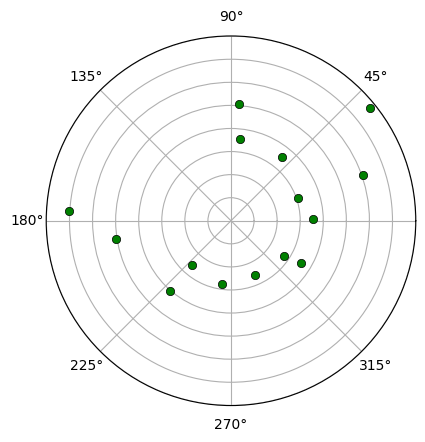

In [341]:
gg = gg.nms()
hts_grasp_group: HTSGraspGroup = HTSGraspGroup()

for ind, grasp in enumerate(gg):            
    hts_grasp = HTSGrasp(grasp, ind)
    z, th = map_grasp(grasp, False)
    hts_grasp.z = z
    hts_grasp.theta = th
    hts_grasp_group.append(hts_grasp)

zs: npt.NDArray[np.float64] = np.array([p.z for p in hts_grasp_group._grasps]).reshape((-1, 1))
ths: npt.NDArray[np.float64] = np.array([p.theta for p in hts_grasp_group._grasps]).reshape((-1, 1))

fig = plt.figure()
ax = fig.add_subplot(projection="polar")
ax.set_yticklabels([])
ax.set_xticklabels(["", *ax.get_xticklabels()[1:]])
plot = ax.scatter(ths, zs, c="green", marker="o", linewidths=0.5, edgecolors="black", zorder=2)
fig.savefig("test.svg", format="svg")

In [356]:

# DISPLAY_INDEX = 0 # 90 deg
# DISPLAY_INDEX = 3 # slightly off 180 deg
# DISPLAY_INDEX = 40 # slightly off 180 deg, higher up
# DISPLAY_INDEX = 70
# DISPLAY_INDEX = 10
DISPLAY_INDEX = 13

# the grasp
grasp = gg[DISPLAY_INDEX]
grasp.depth = 0.01
gripper = grasp.to_open3d_geometry(color=(1, 1, 0.8))    
gripper.compute_vertex_normals()

object_centroid = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1, origin=[*cloud.get_center()[:2], 0.0])

o3d.visualization.draw_geometries([gripper, cloud, object_centroid])

error: XDG_RUNTIME_DIR not set in the environment.
libGL error: glx: failed to create dri3 screen
libGL error: failed to load driver: nouveau


In [315]:
# batch grasps in horizontal layers
SYMMETRY_LAYER_HEIGHT = 0.02

layer_base_height: float = 0.001 + 2*SYMMETRY_LAYER_HEIGHT

# filter cloud and grasps by height
bb: Any = o3d.geometry.AxisAlignedBoundingBox(
    min_bound=[-math.inf, -math.inf, layer_base_height],
    max_bound=[math.inf, math.inf, layer_base_height + SYMMETRY_LAYER_HEIGHT]
)
layer_cloud: o3d.cuda.pybind.geometry.PointCloud = cloud.crop(bb)
layer_grasps = [grasp for grasp in gg if grasp.translation[2] >= layer_base_height and grasp.translation[2] < layer_base_height + SYMMETRY_LAYER_HEIGHT]

bb: Any = o3d.geometry.AxisAlignedBoundingBox(
    min_bound=[-math.inf, -math.inf, -math.inf],
    max_bound=[math.inf, math.inf, layer_base_height]
)
lower_cloud: o3d.cuda.pybind.geometry.PointCloud = cloud.crop(bb)
lower_cloud.paint_uniform_color([0,0,0])
lower_cloud.translate((0, 0, -0.01))


bb: Any = o3d.geometry.AxisAlignedBoundingBox(
    min_bound=[-math.inf, -math.inf, layer_base_height + SYMMETRY_LAYER_HEIGHT],
    max_bound=[math.inf, math.inf, math.inf]
)
upper_cloud: o3d.cuda.pybind.geometry.PointCloud = cloud.crop(bb)
upper_cloud.paint_uniform_color([0,0,0])
upper_cloud.translate((0, 0, 0.01))

grippers = []
for grasp in layer_grasps:
    gripper = grasp.to_open3d_geometry(color=(1, 1, 0.3))
    gripper.compute_vertex_normals()
    grippers.append(gripper)

solo_layer_grasps = GraspNetGroup()
solo_layer_grasps.add(layer_grasps[0])

group: SymmetryGroup = SymmetryGroup(layer_cloud, solo_layer_grasps)

symmetry_gg = GraspNetGroup()

# # perform rotations around the centre
SYMMETRY_ROTATION_STEP = 45
for i in range(SYMMETRY_ROTATION_STEP, 360, SYMMETRY_ROTATION_STEP):
    new_group = group.rotate_about_centre(i)
    if new_group.clouds_are_similar(group, 0.01):
        symmetry_gg.add(new_group.grasps())

symmetry_grippers = []
for grasp in symmetry_gg:
    gripper = grasp.to_open3d_geometry(color=(1, 1, 0.95))
    gripper.compute_vertex_normals()
    symmetry_grippers.append(gripper)

# o3d.visualization.draw_geometries([layer_cloud, grippers[0], lower_cloud, upper_cloud])
o3d.visualization.draw_geometries([layer_cloud, *symmetry_grippers, lower_cloud, upper_cloud, grippers[0]])



error: XDG_RUNTIME_DIR not set in the environment.
libGL error: glx: failed to create dri3 screen
libGL error: failed to load driver: nouveau
